# Klasse verhält sich wie ein Dictionary: u["name"])
you need to define __getitem__(): u["name"] call __getitem__()

Das ist der interessante Fall, den du vermutlich gesehen hast.
    🔑 Schlüsselidee: __getitem__

Wenn eine Klasse diese Methode implementiert, kannst du schreiben:

obj["name"]

    self ist eine Klasseninstanz,
    ➡️ aber sie delegiert den Zugriff an ein internes Dictionary.

In [11]:
class User:
    def __init__(self, name, age):
        self._data = {
            "name": name,
            "age": age
        }

    def __getitem__(self, key):
        print(f" \n### Beweis: getitem called with key={key}")
        return self._data[key]
 
    def func(self):
        return self["name"]
        
    def add_val(self, val):
        self.val=val


In [12]:
u = User("Du", 42)
u.add_val(50)
print("1 :",User.__dict__)
print("2 :",u.func())
print("3 :",u.__dict__)
print("4 :",User.__dict__.keys())
print("5 :",User.__dict__.values())
print("6 :",u["name"]) #call __getitem__(key), python intern rule

1 : {'__module__': '__main__', '__init__': <function User.__init__ at 0x000001B8A950DBC0>, '__getitem__': <function User.__getitem__ at 0x000001B8A950E480>, 'func': <function User.func at 0x000001B8A950CFE0>, 'add_val': <function User.add_val at 0x000001B8A950D800>, '__dict__': <attribute '__dict__' of 'User' objects>, '__weakref__': <attribute '__weakref__' of 'User' objects>, '__doc__': None}
 
### Beweis: getitem called with key=name
2 : Du
3 : {'_data': {'name': 'Du', 'age': 42}, 'val': 50}
4 : dict_keys(['__module__', '__init__', '__getitem__', 'func', 'add_val', '__dict__', '__weakref__', '__doc__'])
5 : dict_values(['__main__', <function User.__init__ at 0x000001B8A950DBC0>, <function User.__getitem__ at 0x000001B8A950E480>, <function User.func at 0x000001B8A950CFE0>, <function User.add_val at 0x000001B8A950D800>, <attribute '__dict__' of 'User' objects>, <attribute '__weakref__' of 'User' objects>, None])
 
### Beweis: getitem called with key=name
6 : Du


# Klasse erbt von dict, dann wird Klasse auch gleichzeitig ein Dict()
Sehr verbreitet z. B. in Frameworks (FastAPI, Pydantic, Django intern).

    ➡️ self IST ein Dictionary,
    ➡️ aber gleichzeitig eine Klasseninstanz.

In [22]:
class User(dict):
    myage=50
    def getname(self):
        return self["name"]

u = User(name="Du", age=35, beruf="IT-fachman")
print("1: ", u["name"])
print("2: ", u.getname())
print("3: ", User.__dict__)
print("4: ", User.__dict__["getname"])
#print(User.__dict__["'__dict__"])
print("5: ", u.__dict__)

print("6: ", u["name"])
print("7: ", u.myage)
print("8: ", User.myage)
#print(u.__dict__["name"]) interner Attribut-Speicher

1:  Du
2:  Du
3:  {'__module__': '__main__', 'myage': 50, 'getname': <function User.getname at 0x000001B8A950ED40>, '__dict__': <attribute '__dict__' of 'User' objects>, '__weakref__': <attribute '__weakref__' of 'User' objects>, '__doc__': None}
4:  <function User.getname at 0x000001B8A950ED40>
5:  {}
6:  Du
7:  50
8:  50


# Realistische Praxisbeispiele (die du sehr wahrscheinlich gesehen hast)
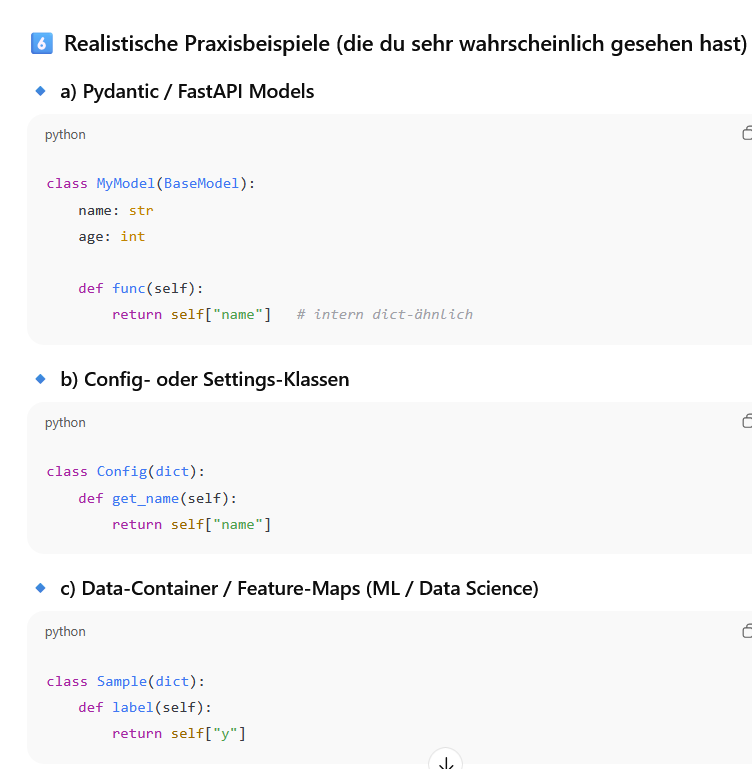

In [23]:
# dict: {"name": "Du", "age": 50} => key:value, always as pairwise
class MyModel(dict):
    name: str
    age: int

    def func(self):
        return self["name"]   # intern dict-ähnlich


In [25]:
# dict wird vererbt, mdl wird ein dict
mdl= MyModel(name="Du", age=35) #   wie {"name": "Du", "age": 50}
MyModel.str="Chen"
print("1: ", mdl["name"])
#print(mdl.name)
print("2: ", MyModel.__mro__)
MyModel.str

1:  Du
2:  (<class '__main__.MyModel'>, <class 'dict'>, <class 'object'>)


'Chen'

# Formale Regel 
Python übersetzt nämlich: obj["name"] =  type(obj).__getitem__(obj, "name")

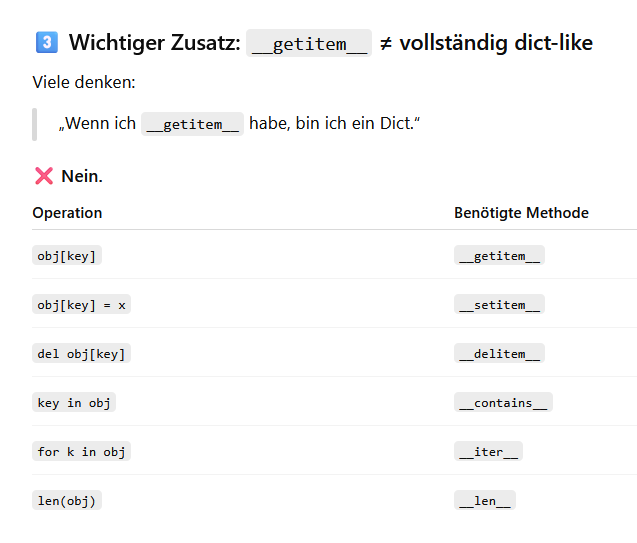


In [33]:
class DebugDict:
    def __init__(self):
        self.store = {"name": "Du"} # define a dict

    def __getitem__(self, key):
        print(f"getitem called with key={key}")
        return self.store[key]

    def func(self):
        return self["name"]


In [34]:
d = DebugDict()
print(d.func()) # self["name"] call __getitem__(self, key)


getitem called with key=name
Du


# __getattribute__ wird von der Basisklasse object definiert.
a.x = type(a).__getattribute__(a, "x")

MRO: Method Resolution Order

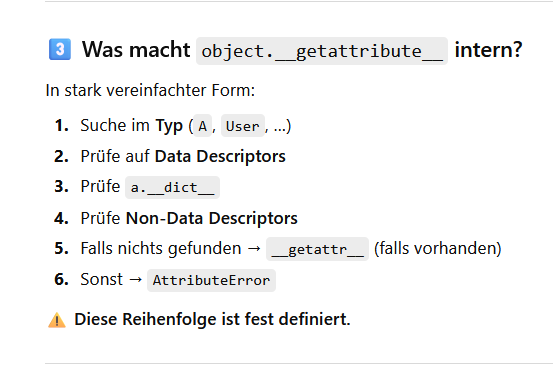


In [36]:
class SmartPhone:
    def __init__(self, modell):
        self.modell = modell
        self.akku = 85

    def __getattribute__(self, name):
        # 1. Wir loggen den Versuch
        print(f"[Log]: Zugriff auf Attribut '{name}'")

        # 2. Wir manipulieren das Ergebnis (optional)
        if name == "akku":
            wert = super().__getattribute__(name)
            return f"{wert}% Ladung"

        # 3. Standard-Verhalten via super() aufrufen
        return super().__getattribute__(name)

# Nutzung
handy = SmartPhone("iPhone 15")

print("1: ", handy.modell) # Löst __getattribute__ aus
print("2: ",handy.akku)   # Löst __getattribute__ aus und wird formatiert


[Log]: Zugriff auf Attribut 'modell'
1:  iPhone 15
[Log]: Zugriff auf Attribut 'akku'
2:  85% Ladung


In [32]:
class A:
    x=50
    def __init__(self, x,y):
        self.x=x
        self.y=y

a = A(10,20)
print("1: ", A.__getattribute__)
print("2: ",object.__getattribute__)

print("3: ",a)
print("4: ",A.x)
print("5: ",a.x)
print("6: ",a.__dict__)
# print(len(a)) __len__() should be defined by user for class A
mydict= {"name":"Chen", "age": 50}
print(len(mydict)) # dict has defined method __len__() by python intern
A.__mro__

1:  <slot wrapper '__getattribute__' of 'object' objects>
2:  <slot wrapper '__getattribute__' of 'object' objects>
3:  <__main__.A object at 0x000001B8A907D880>
4:  50
5:  10
6:  {'x': 10, 'y': 20}
2


(__main__.A, object)

# 2️⃣ Grundprinzip: „Syntax → Methode“
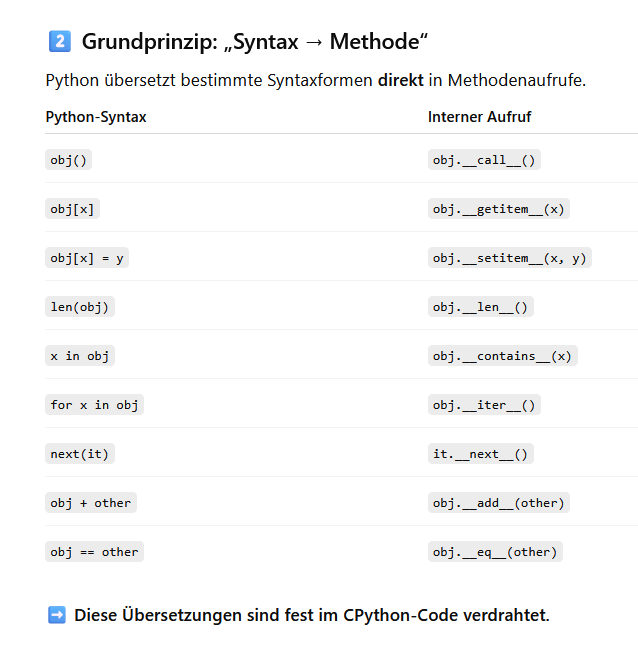

# ✅ Komposition (oft besser!)
## Vererbung von dict
class User(dict):
    ...


- ✔️ Vorteil: schnell, bequem
- ❌ Nachteil: schwer zu kontrollieren, API „leckt“

# Wenn Sie zwei Dictionaries haben, entscheidet allein die Implementierung Ihrer
__getitem__  Methode darüber, welches Dictionary beim Aufruf von self["name"] verwendet wird.

In [37]:
# Komposition (oft besser!)
class User:
    def __init__(self, name, age):
        self._data =  {"name": name, "age": age}
        self._data1 = {"name": name, "age": age}


    def __getitem__(self, key): # entschedet call  dict: _data, nicht _data1
        print("# __getitem__ called")
        return self._data[key]

    def func(self):
        return self["name"]

    # Hier fehlte das 'def'
    def add_country(self, adress):
        self.adress = adress
        
    def add_adr_in_dict(self, adress):
    # Richtig für Komposition:
        self._data["adress"] = adress 
       
    def get_adr_in_dict(self):
        return self["adress"]

    def get_country(self):
        return self.adress


In [38]:
u = User("Chen", 50)
u._data1["name"]="Wang"
u.add_adr_in_dict("Berlin")
u.add_country("Germany")

print("func:#", u.func())
print(u.get_adr_in_dict())
print("country:#", u.adress)
print("country:#", u.get_country())
print("u._data:#", u._data)
print("u.__dict__:#", u.__dict__)


# __getitem__ called
func:# Chen
# __getitem__ called
Berlin
country:# Germany
country:# Germany
u._data:# {'name': 'Chen', 'age': 50, 'adress': 'Berlin'}
u.__dict__:# {'_data': {'name': 'Chen', 'age': 50, 'adress': 'Berlin'}, '_data1': {'name': 'Wang', 'age': 50}, 'adress': 'Germany'}


# 1️⃣ Konkretes, echtes Beispiel (Pydantic)

In [39]:
from pydantic import BaseModel

class User(BaseModel):
    name: str
    age: int

    def func(self):
        return self.name


In [40]:
u = User(name="Du", age=35)

print(u.func())
print(u.name)
print(u.dict())


Du
Du
{'name': 'Du', 'age': 35}


C:\Users\wug2si\AppData\Local\Temp\ipykernel_28984\4162158313.py:5: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  print(u.dict())
